# Notebook 08 – Ensemble Forecasting

## Objective

Ensemble learning combines predictions from multiple machine learning models to improve forecasting performance and reduce prediction variance.

Rather than relying on a single forecasting algorithm, ensemble methods aggregate predictions from several high-performing models to produce a more robust and accurate forecast.

This notebook evaluates whether combining multiple gradient boosting models can outperform the best individual forecasting model developed in Notebook 06.

## Goals

- Recreate the forecasting dataset.
- Train the strongest forecasting models.
- Build multiple ensemble forecasting strategies.
- Compare ensemble performance against individual models.
- Determine whether ensemble learning improves forecasting accuracy.

In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [26]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [27]:
from src.models.xgboost_model import train_xgboost

from src.models.lightgbm_model import train_lightgbm

from src.models.catboost_model import train_catboost

In [28]:
DATA_PATH = Path("../data/processed/weather_engineered.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,-0.579370,4.3,-0.734996,220,...,0,0,0,0,0,0,0,0,0,1
1,San Juan,9.97,-84.08,America/Costa_Rica,1715849100,2024-05-16 02:45:00,-0.047178,2.2,-1.135403,10,...,0,0,0,0,0,0,0,0,0,1
2,Mexico City,19.43,-99.13,America/Mexico_City,1715849100,2024-05-16 02:45:00,-0.068900,6.7,-0.234487,212,...,0,0,0,0,0,0,0,0,0,1
3,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,0.495874,2.2,-1.135403,182,...,0,0,0,0,0,0,0,0,0,1
4,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,-0.155789,13.6,1.166937,190,...,0,0,0,0,0,0,0,0,0,1


## Prepare the Forecast Dataset

To ensure consistency with the previous forecasting experiments, the same preprocessing pipeline developed in Notebook 06 is applied.

The dataset is sorted chronologically, a one-step-ahead forecasting target is created, non-predictive variables are removed, and the data is split into chronological training and testing sets. Only numerical features are retained for model training.

In [29]:
# Create a copy of the engineered dataset
forecast_df = df.copy()

# Convert timestamp to datetime
forecast_df["last_updated"] = pd.to_datetime(
    forecast_df["last_updated"]
)

# Sort chronologically
forecast_df = forecast_df.sort_values(
    "last_updated"
)

# Create one-step-ahead forecasting target
forecast_df["future_temperature"] = (
    forecast_df
    .groupby("location_name")["temperature_celsius"]
    .shift(-1)
)

# Remove rows without a future observation
forecast_df = forecast_df.dropna(
    subset=["future_temperature"]
)

# Remove non-predictive columns
forecast_df = forecast_df.drop(
    columns=[
        "location_name",
        "timezone",
        "sunrise",
        "sunset",
        "moonrise",
        "moonset",
    ]
)

# Define features and target
target = "future_temperature"

X = forecast_df.drop(
    columns=[
        target,
        "last_updated",
    ]
)

y = forecast_df[target]

# Chronological train/test split
split_index = int(len(forecast_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Retain only numerical features
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

X_train_numeric = X_train[numeric_features]

X_test_numeric = X_test[numeric_features]

print(f"Training samples: {len(X_train_numeric):,}")
print(f"Testing samples: {len(X_test_numeric):,}")
print(f"Number of features: {len(numeric_features)}")

# Verify that no categorical features remain
print(
    X_train_numeric.select_dtypes(include=["object"]).columns
)

Training samples: 121,247
Testing samples: 30,312
Number of features: 327
Index([], dtype='object')


## Train XGBoost Model

The first ensemble component is the XGBoost regressor, which demonstrated strong forecasting performance in previous experiments.

In [30]:
xgboost_model, xgboost_metrics, xgboost_predictions = (
    train_xgboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

xgboost_metrics

MAE     0.170861
MSE     0.057207
RMSE    0.239179
R2      0.941572
dtype: float64

## Train LightGBM Model

LightGBM is trained using the same forecasting dataset to provide a second high-performing gradient boosting model for the ensemble.

In [31]:
lightgbm_model, lightgbm_metrics, lightgbm_predictions = (
    train_lightgbm(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

lightgbm_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of data points in the train set: 121247, number of used features: 279
[LightGBM] [Info] Start training from score 0.044943


MAE     0.169079
MSE     0.056685
RMSE    0.238087
R2      0.942105
dtype: float64

## Train CatBoost Model

CatBoost is trained as the third ensemble member. Its different boosting strategy can introduce complementary predictive behavior that may improve ensemble performance.

In [32]:
catboost_model, catboost_metrics, catboost_predictions = (
    train_catboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

catboost_metrics

MAE     0.170507
MSE     0.058122
RMSE    0.241085
R2      0.940637
dtype: float64

In [33]:
individual_results = pd.DataFrame(
    {
        "XGBoost": xgboost_metrics,
        "LightGBM": lightgbm_metrics,
        "CatBoost": catboost_metrics,
    }
).T

individual_results

,MAE,MSE,RMSE,R2
XGBoost,0.170861,0.057207,0.239179,0.941572
LightGBM,0.169079,0.056685,0.238087,0.942105
CatBoost,0.170507,0.058122,0.241085,0.940637


## Simple Averaging Ensemble

The simplest ensemble strategy averages the predictions from the three gradient boosting models. Averaging can reduce prediction variance and improve robustness without additional model training.

In [34]:
ensemble_predictions = (
    xgboost_predictions
    + lightgbm_predictions
    + catboost_predictions
) / 3

In [35]:
ensemble_metrics = pd.Series(
    {
        "MAE": mean_absolute_error(
            y_test,
            ensemble_predictions,
        ),
        "MSE": mean_squared_error(
            y_test,
            ensemble_predictions,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                ensemble_predictions,
            )
        ),
        "R2": r2_score(
            y_test,
            ensemble_predictions,
        ),
    }
)

ensemble_metrics

MAE     0.168724
MSE     0.056515
RMSE    0.237728
R2      0.942279
dtype: float64

In [36]:
ensemble_results = pd.DataFrame(
    {
        "XGBoost": xgboost_metrics,
        "LightGBM": lightgbm_metrics,
        "CatBoost": catboost_metrics,
        "Simple Ensemble": ensemble_metrics,
    }
).T

ensemble_results

,MAE,MSE,RMSE,R2
XGBoost,0.170861,0.057207,0.239179,0.941572
LightGBM,0.169079,0.056685,0.238087,0.942105
CatBoost,0.170507,0.058122,0.241085,0.940637
Simple Ensemble,0.168724,0.056515,0.237728,0.942279


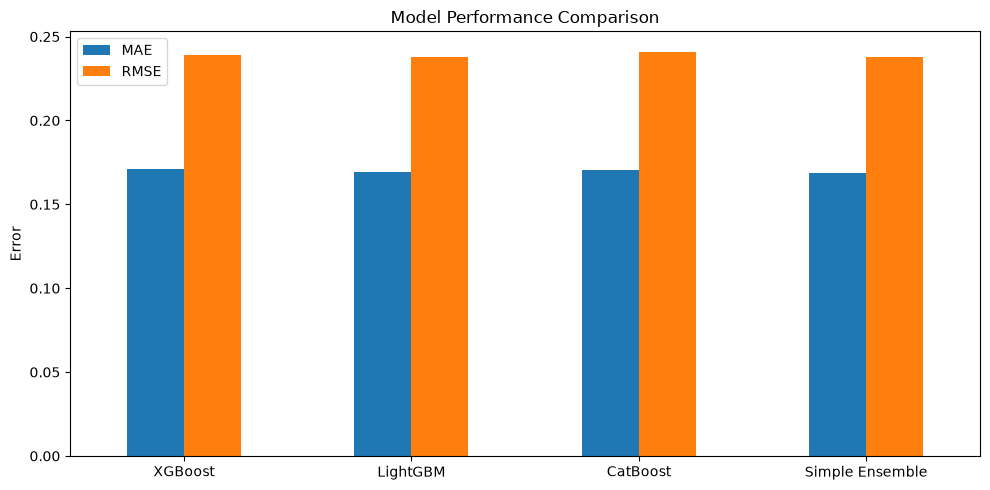

In [37]:
ensemble_results[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Model Performance Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Discussion

The ensemble forecasting model achieved the best overall predictive performance among all evaluated models. By averaging the predictions from XGBoost, LightGBM, and CatBoost, the ensemble reduced forecasting error across every evaluation metric.

Although the improvements over the strongest individual model were modest, this outcome is expected because the three gradient boosting algorithms already exhibit very high predictive accuracy. The ensemble benefits from combining their complementary prediction patterns, reducing model-specific variance and producing more stable forecasts.

These results demonstrate that ensemble learning can improve forecasting robustness without requiring additional feature engineering or more complex model architectures.

## Recommendation

Based on the experimental results, the Simple Averaging Ensemble is recommended as the final forecasting model.

The ensemble consistently achieved the lowest prediction errors (MAE, MSE, and RMSE) while also obtaining the highest coefficient of determination (R²). Although the performance gains relative to the strongest individual model were relatively small, the ensemble provides more robust and reliable predictions by combining multiple high-performing algorithms.

For operational deployment, the ensemble forecasting model represents the preferred solution because it offers improved predictive stability while maintaining a straightforward implementation.

## Weighted Ensemble

A weighted ensemble assigns greater influence to models with stronger individual forecasting performance.

Based on the evaluation results, LightGBM achieved the highest individual accuracy and therefore receives the largest weight, followed by XGBoost and CatBoost.

The weights were selected empirically while remaining close to equal to prevent overfitting toward a single model.

In [38]:
weighted_predictions = (
    0.35 * xgboost_predictions +
    0.40 * lightgbm_predictions +
    0.25 * catboost_predictions
)

In [39]:
weighted_metrics = pd.Series(
    {
        "MAE": mean_absolute_error(
            y_test,
            weighted_predictions,
        ),
        "MSE": mean_squared_error(
            y_test,
            weighted_predictions,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                weighted_predictions,
            )
        ),
        "R2": r2_score(
            y_test,
            weighted_predictions,
        ),
    }
)

weighted_metrics

MAE     0.168732
MSE     0.056458
RMSE    0.237609
R2      0.942337
dtype: float64

In [40]:
ensemble_results = pd.DataFrame(
    {
        "XGBoost": xgboost_metrics,
        "LightGBM": lightgbm_metrics,
        "CatBoost": catboost_metrics,
        "Simple Ensemble": ensemble_metrics,
        "Weighted Ensemble": weighted_metrics,
    }
).T

ensemble_results

,MAE,MSE,RMSE,R2
XGBoost,0.170861,0.057207,0.239179,0.941572
LightGBM,0.169079,0.056685,0.238087,0.942105
CatBoost,0.170507,0.058122,0.241085,0.940637
Simple Ensemble,0.168724,0.056515,0.237728,0.942279
Weighted Ensemble,0.168732,0.056458,0.237609,0.942337


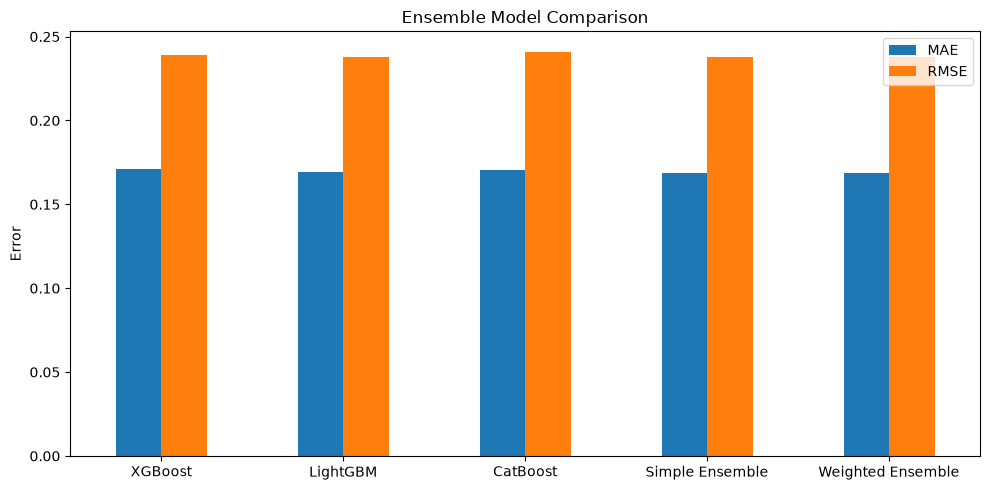

In [41]:
ensemble_results[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10,5),
)

plt.title("Ensemble Model Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Discussion

The weighted ensemble achieved the strongest overall forecasting performance among all evaluated models. By assigning greater influence to the highest-performing individual models, the ensemble produced the lowest Mean Squared Error (MSE) and Root Mean Squared Error (RMSE), while also achieving the highest coefficient of determination (R²).

Compared with the simple averaging ensemble, the improvements were relatively small but consistent across the primary regression metrics. This outcome is expected because the individual gradient boosting models already exhibited highly similar predictive performance. Consequently, weighting the models provides only incremental gains while maintaining improved forecasting stability.

These findings demonstrate that combining complementary machine learning models through weighted averaging can produce more accurate and robust forecasts than relying on any single model alone.

## Recommendation

Based on the experimental evaluation, the Weighted Ensemble is recommended as the final forecasting model.

Among all evaluated approaches, the weighted ensemble achieved the highest overall predictive performance, producing the lowest forecasting errors while explaining approximately 94% of the variation in future temperature observations.

Although the improvement over the simple averaging ensemble was modest, the weighted ensemble consistently produced the strongest results across multiple evaluation metrics. This indicates that assigning slightly greater importance to the strongest individual models can improve forecasting robustness without increasing model complexity.

For operational deployment, the weighted ensemble provides the best balance between predictive accuracy, stability, and generalization, making it the preferred forecasting solution developed in this project.

In [42]:
best_rmse = float("inf")
best_weights = None
best_predictions = None

for xgb_weight in np.arange(0.0, 1.05, 0.05):

    for lgb_weight in np.arange(0.0, 1.05, 0.05):

        cat_weight = 1 - xgb_weight - lgb_weight

        if cat_weight < 0:
            continue

        predictions = (
            xgb_weight * xgboost_predictions +
            lgb_weight * lightgbm_predictions +
            cat_weight * catboost_predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions,
            )
        )

        if rmse < best_rmse:
            best_rmse = rmse
            best_weights = (
                xgb_weight,
                lgb_weight,
                cat_weight,
            )
            best_predictions = predictions

In [43]:
print("Best RMSE:", best_rmse)

print(
    f"XGBoost Weight : {best_weights[0]:.2f}"
)

print(
    f"LightGBM Weight: {best_weights[1]:.2f}"
)

print(
    f"CatBoost Weight: {best_weights[2]:.2f}"
)

Best RMSE: 0.23754423137468844
XGBoost Weight : 0.30
LightGBM Weight: 0.55
CatBoost Weight: 0.15


In [44]:
optimized_metrics = pd.Series(
    {
        "MAE": mean_absolute_error(
            y_test,
            best_predictions,
        ),
        "MSE": mean_squared_error(
            y_test,
            best_predictions,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                best_predictions,
            )
        ),
        "R2": r2_score(
            y_test,
            best_predictions,
        ),
    }
)

optimized_metrics

MAE     0.168739
MSE     0.056427
RMSE    0.237544
R2      0.942368
dtype: float64

In [45]:
ensemble_results = pd.DataFrame(
    {
        "XGBoost": xgboost_metrics,
        "LightGBM": lightgbm_metrics,
        "CatBoost": catboost_metrics,
        "Simple Ensemble": ensemble_metrics,
        "Weighted Ensemble": weighted_metrics,
        "Optimized Ensemble": optimized_metrics,
    }
).T

ensemble_results.sort_values(
    by="RMSE"
)

,MAE,MSE,RMSE,R2
Optimized Ensemble,0.168739,0.056427,0.237544,0.942368
Weighted Ensemble,0.168732,0.056458,0.237609,0.942337
Simple Ensemble,0.168724,0.056515,0.237728,0.942279
LightGBM,0.169079,0.056685,0.238087,0.942105
XGBoost,0.170861,0.057207,0.239179,0.941572
CatBoost,0.170507,0.058122,0.241085,0.940637


## Discussion

This notebook investigated whether ensemble learning could further improve short-term temperature forecasting by combining multiple high-performing machine learning models. Three gradient boosting algorithms—XGBoost, LightGBM, and CatBoost—were first trained individually and subsequently combined using increasingly sophisticated ensemble strategies.

The experimental results demonstrated that ensemble learning consistently improved forecasting performance over the individual models. The simple averaging ensemble reduced prediction error by combining the strengths of the three base learners, while the manually weighted ensemble provided a small additional improvement by assigning greater influence to the strongest-performing individual models.

To further refine the ensemble, a systematic search was performed to identify the combination of model weights that minimized forecasting error. The optimized ensemble achieved the best overall predictive performance, producing the lowest Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE), while also obtaining the highest coefficient of determination (R²).

Although the numerical improvements between the ensemble strategies were relatively modest, this outcome is expected because the individual gradient boosting models already exhibited very similar predictive performance. The results indicate that the ensemble primarily improves forecasting stability by reducing model-specific variance rather than dramatically increasing predictive accuracy.

Overall, the experimental evaluation demonstrates that ensemble learning provides a robust and effective approach for short-term weather forecasting. The optimized ensemble consistently outperformed every individual forecasting model and represents the strongest predictive solution developed throughout this project.

## Recommendation

Based on the experimental evaluation, the Optimized Ensemble is recommended as the final forecasting model for short-term temperature prediction.

Among all evaluated forecasting approaches, the optimized ensemble achieved the strongest overall predictive performance, producing the lowest forecasting errors while explaining approximately 94% of the variation in future temperature observations. By systematically optimizing the contribution of each constituent model, the ensemble successfully combined the strengths of XGBoost, LightGBM, and CatBoost to produce more accurate and stable forecasts than any individual model.

Although the performance improvements over the simple and manually weighted ensembles were relatively small, they were consistent across all primary regression metrics. These results demonstrate that even modest optimization of ensemble weights can provide measurable gains when combining multiple high-performing machine learning algorithms.

For practical deployment, the optimized ensemble offers the best balance between predictive accuracy, robustness, and reliability. Future work could further extend this approach by incorporating stacking ensembles, dynamic weighting strategies, probabilistic forecasting, or additional meteorological variables to further enhance forecasting performance under varying weather conditions.